# Relatorio de teste com logs Sysmon
Execute as celulas em ordem para gerar metricas, SHAP/LIME e o relatorio final.

In [38]:
import os
import sys
import subprocess
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import ipaddress
import joblib
import matplotlib.pyplot as plt

def ensure_package(import_name, pip_name=None):
    try:
        __import__(import_name)
        return
    except Exception:
        pkg = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

ensure_package("Evtx", "python-evtx")
ensure_package("shap")
ensure_package("lime")

from Evtx.Evtx import Evtx
import xml.etree.ElementTree as ET
import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

In [59]:
ROOT = Path("..").resolve()
MODEL_PATH = ROOT / "Train" / "modelo_ransomware.joblib"
DATASET_PATH = ROOT / "Datasets" / "LMD-2023-dataset.csv"
LOGS_DIR = ROOT / "RansomwaresLogs"

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"
assert LOGS_DIR.exists(), f"Logs dir not found: {LOGS_DIR}"

rf = joblib.load(MODEL_PATH)
rf

RandomForestClassifier(n_jobs=-1, random_state=42)

In [60]:
import joblib

# The columns that the model was trained on:
reliable_features = [
    "IntegrityLevel",
    "Image",
    "User",
    "ParentImage",
    "ParentUser"
]

# We need to construct X_train_raw identically to how we constructed it in train_v2.ipynb
# This is necessary because SHAP uses X_train for baseline context.
df_train = pd.read_csv(DATASET_PATH, low_memory=False)
df_train = df_train[df_train["Label"] != 2].copy()

# Rename columns to match what test logic uses (just like in train_v2)
if 'Execution_ProcessID' in df_train.columns:
    df_train = df_train.drop(columns=['Execution_ProcessID']) 

df_train = df_train.rename(columns={"ProcessID": "ProcessId", "ParentProcessID": "ParentProcessId", "ThreadID": "ThreadId"})
df_train = df_train.loc[:, ~df_train.columns.duplicated()]

y_train = df_train["Label"]
X_train_raw = df_train[reliable_features].copy()

def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except Exception:
        return 0

for col in ["SourceIp", "DestinationIp"]:
    if col in X_train_raw.columns:
        X_train_raw[col] = X_train_raw[col].astype(str).apply(ip_to_int)

numeric_features = X_train_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_raw.select_dtypes(include=["object"]).columns.tolist()

# Load the saved encoders from the training phase instead of re-fitting!
encoders = joblib.load(ROOT / "Train" / "encoders.joblib")

X_train = X_train_raw.copy()
for col in categorical_features:
    # We use the loaded encoder!
    le = encoders[col]
    
    # We need to handle classes that are not in the encoder (unseen data)
    # The safest way in inference is to map them to an unseen value (-1)
    mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
    X_train[col] = X_train[col].astype(str).fillna("").map(lambda x: mapping.get(x, -1)).astype(int)

train_dtypes = X_train_raw.dtypes

def align_and_preprocess(df_raw):
    df = df_raw.copy()
    
    # Apply exactly the same preprocessing filters
    for col in X_train_raw.columns:
        if col not in df.columns:
            if train_dtypes[col].kind in "if":
                df[col] = 0
            else:
                df[col] = ""
                
    df = df[X_train_raw.columns]

    for col in X_train_raw.columns:
        if train_dtypes[col].kind in "if":
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = df[col].astype(str).fillna("")

    for col in ["SourceIp", "DestinationIp"]:
        if col in df.columns:
            df[col] = df[col].astype(str).apply(ip_to_int)

    for col in categorical_features:
        le = encoders[col]
        mapping = {cls: idx for idx, cls in enumerate(le.classes_)}
        df[col] = df[col].astype(str).map(lambda x: mapping.get(x, -1)).astype(int)

    return df


In [61]:
def parse_evtx_file(path):
    rows = []
    with Evtx(str(path)) as log:
        for record in log.records():
            xml = record.xml()
            root = ET.fromstring(xml)
            row = {"_log_file": path.name}

            system = root.find("{*}System")
            if system is not None:
                for child in system:
                    tag = child.tag.split("}")[-1]
                    if tag == "TimeCreated":
                        row["SystemTime"] = child.attrib.get("SystemTime")
                    elif tag == "Provider":
                        if "Name" in child.attrib:
                            row["Name"] = child.attrib.get("Name")
                        if "Guid" in child.attrib:
                            row["Guid"] = child.attrib.get("Guid")
                    elif tag == "Execution":
                        if "ProcessID" in child.attrib:
                            row["ProcessID"] = child.attrib.get("ProcessID")
                        if "ThreadID" in child.attrib:
                            row["ThreadID"] = child.attrib.get("ThreadID")
                    elif tag == "Security":
                        if "UserID" in child.attrib:
                            row["UserID"] = child.attrib.get("UserID")
                    elif tag == "Correlation":
                        if "ActivityID" in child.attrib:
                            row["Correlation"] = child.attrib.get("ActivityID")
                    else:
                        if child.text is not None:
                            row[tag] = child.text

            event_data = root.find("{*}EventData")
            if event_data is not None:
                for d in event_data.findall("{*}Data"):
                    name = d.attrib.get("Name")
                    if name:
                        row[name] = d.text

            user_data = root.find("{*}UserData")
            if user_data is not None:
                for elem in user_data.iter():
                    if elem is user_data:
                        continue
                    tag = elem.tag.split("}")[-1]
                    if elem.text is not None and tag not in row:
                        row[tag] = elem.text

            rows.append(row)
    return rows

def normalize_logs(df):
    df = df.copy()
    if "ProcessID" in df.columns and "ProcessId" not in df.columns:
        df["ProcessId"] = df["ProcessID"]
    if "ThreadID" in df.columns and "ThreadId" not in df.columns:
        df["ThreadId"] = df["ThreadID"]
    if "ParentProcessID" in df.columns and "ParentProcessId" not in df.columns:
        df["ParentProcessId"] = df["ParentProcessID"]
    if "SystemTime" in df.columns and "UtcTime" not in df.columns:
        df["UtcTime"] = df["SystemTime"]
    return df

all_records = []
for p in sorted(LOGS_DIR.glob("*.evtx")):
    all_records.extend(parse_evtx_file(p))

df_logs = pd.DataFrame(all_records)
df_logs = normalize_logs(df_logs)
print("events:", len(df_logs), "columns:", len(df_logs.columns))
df_logs.head()

events: 685 columns: 50


,_log_file,Name,Guid,EventID,Version,Level,Task,Opcode,Keywords,SystemTime,...,EventType,TargetObject,Details,QueryName,QueryStatus,QueryResults,TargetFilename,CreationUtcTime,PreviousCreationUtcTime,ThreadId
0,cerber.evtx,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,2026-05-25 01:40:08.988808+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4772
1,cerber.evtx,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,2026-05-25 01:40:31.264664+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4772
2,cerber.evtx,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},13,2,4,13,0,0x8000000000000000,2026-05-25 01:40:31.278019+00:00,...,SetValue,HKU\S-1-5-21-776455688-155246198-3229114385-10...,Binary Data,NaN,NaN,NaN,NaN,NaN,NaN,4772
3,cerber.evtx,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,2026-05-25 01:40:35.336962+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4772
4,cerber.evtx,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,2026-05-25 01:40:35.349861+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4772


In [69]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

X_logs = align_and_preprocess(df_logs)

pred_original = rf.predict(X_logs)
classes = list(getattr(rf, "classes_", [0, 1]))
pos_label = 1 if 1 in classes else classes[-1]

if hasattr(rf, "predict_proba"):
    prob = rf.predict_proba(X_logs)
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    prob_pos = prob[:, pos_index]
else:
    prob_pos = np.full(len(pred_original), np.nan)

# Custom threshold for prediction: > 0.15
threshold = 0.15
pred = np.where(prob_pos > threshold, pos_label, 0)

df_logs["pred_label"] = pred
df_logs["prob_ransomware"] = prob_pos

y_true = np.full(len(df_logs), pos_label)
acc = accuracy_score(y_true, pred)
rec = recall_score(y_true, pred, pos_label=pos_label)
cm = confusion_matrix(y_true, pred, labels=[0, pos_label])

print("Threshold applied:", threshold)
print("accuracy:", acc)
print("recall:", rec)
print("confusion_matrix (rows=true, cols=pred):")
print(cm)
print(classification_report(y_true, pred, labels=[0, pos_label]))

summary = df_logs.groupby("_log_file").agg(
    total_events=("pred_label", "size"),
    predicted_ransomware_rate=("pred_label", lambda x: float(np.mean(x == pos_label))),
    avg_prob_ransomware=("prob_ransomware", "mean"),
    max_prob_ransomware=("prob_ransomware", "max")
).reset_index()

# Classificar o LOG inteiro caso qualquer evento, media de eventos, ou taxa de eventos quebre a proporcao predefinida
summary["log_pred_label"] = np.where(
    (summary["predicted_ransomware_rate"] > 0) | (summary["avg_prob_ransomware"] > threshold) | (summary["max_prob_ransomware"] > threshold),
    pos_label,
    0,
)

print("\nPredicao por log (Considerado Ransomware se Prob > 0.15):")
for _, row in summary.iterrows():
    label_txt = "RANSOMWARE" if row["log_pred_label"] == pos_label else "NAO RANSOMWARE"
    print(f"- {row['_log_file']}: {label_txt} (rate={row['predicted_ransomware_rate']:.2f}, avg_prob={row['avg_prob_ransomware']:.3f}, max_prob={row['max_prob_ransomware']:.3f})")

summary


Threshold applied: 0.15
accuracy: 0.9766423357664233
recall: 0.9766423357664233
confusion_matrix (rows=true, cols=pred):
[[  0   0]
 [ 16 669]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.98      0.99       685

    accuracy                           0.98       685
   macro avg       0.50      0.49      0.49       685
weighted avg       1.00      0.98      0.99       685


Predicao por log (Considerado Ransomware se Prob > 0.15):
- cerber.evtx: RANSOMWARE (rate=1.00, avg_prob=0.432, max_prob=0.837)
- locky.evtx: RANSOMWARE (rate=0.82, avg_prob=0.422, max_prob=0.837)
- teslacrypt.evtx: RANSOMWARE (rate=0.89, avg_prob=0.433, max_prob=0.844)
- wannacry.evtx: RANSOMWARE (rate=0.97, avg_prob=0.414, max_prob=0.837)


,_log_file,total_events,predicted_ransomware_rate,avg_prob_ransomware,max_prob_ransomware,log_pred_label
0,cerber.evtx,478,1.000000,0.432123,0.837295,1
1,locky.evtx,33,0.818182,0.421836,0.837295,1
2,teslacrypt.evtx,64,0.890625,0.432993,0.843734,1
3,wannacry.evtx,110,0.972727,0.413617,0.837295,1


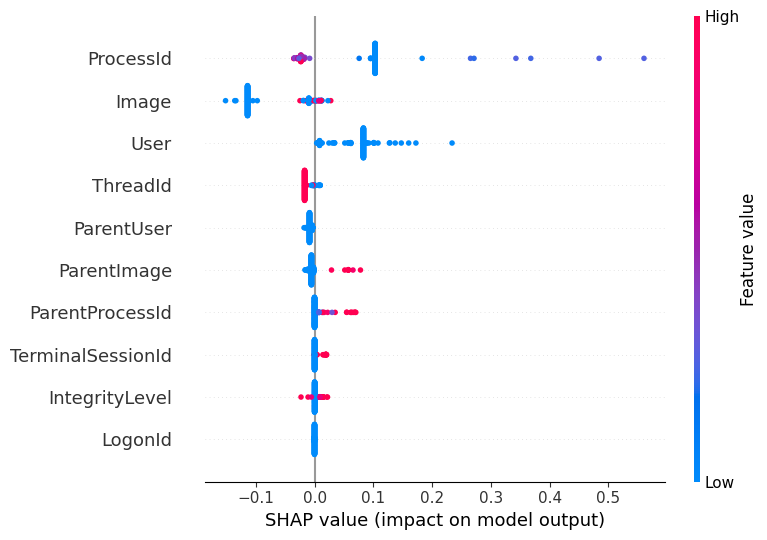

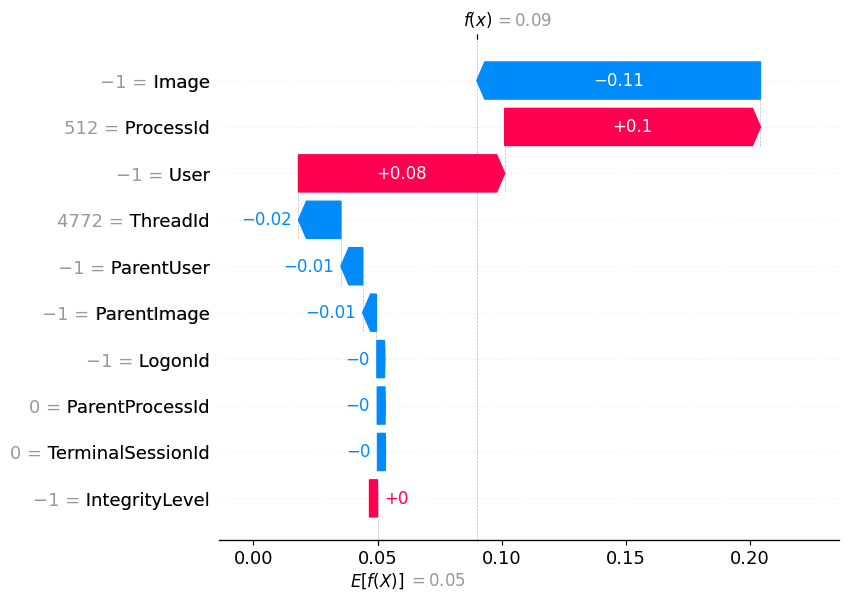

In [43]:
sample_logs = X_logs.sample(n=min(200, len(X_logs)), random_state=42)
train_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42)

explainer = shap.TreeExplainer(rf, data=train_sample)
sv_all = explainer.shap_values(sample_logs)

if isinstance(sv_all, list):
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[pos_index]
elif isinstance(sv_all, np.ndarray) and sv_all.ndim == 3:
    pos_index = classes.index(pos_label) if pos_label in classes else 0
    sv = sv_all[:, :, pos_index]
else:
    sv = sv_all

shap.summary_plot(sv, sample_logs, show=True)
plt.show()

instance_idx = 0
sv_row = sv[instance_idx] if hasattr(sv, "__getitem__") else np.array(sv)[instance_idx]
row = sample_logs.iloc[instance_idx]
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.array(base_value).ravel()
    base_value = float(base_value[pos_index]) if len(base_value) > pos_index else float(base_value[0])
else:
    base_value = float(base_value)

try:
    exp = shap.Explanation(
        values=sv_row,
        base_values=base_value,
        data=row.values,
        feature_names=sample_logs.columns.tolist(),
    )
    shap.plots.waterfall(exp, max_display=12)
    plt.show()
except Exception as e:
    print("waterfall failed:", e)

[('ParentUser <= 1.00', -0.05420412692895096), ('ParentProcessId > 0.00', 0.015127124116058502), ('ParentImage > 1.00', 0.014300153696305877), ('TerminalSessionId > 0.00', 0.007691643978302003), ('Image <= 498.00', -0.007511214875129716), ('ProcessId > 5520.00', -0.00678948360706113), ('IntegrityLevel > 0.00', 0.006432516816735264), ('ThreadId <= 6760.00', -0.002959622518630563), ('LogonId <= 0.00', 0.0025607021396134577), ('User <= 9.00', 0.00021802728791813877)]


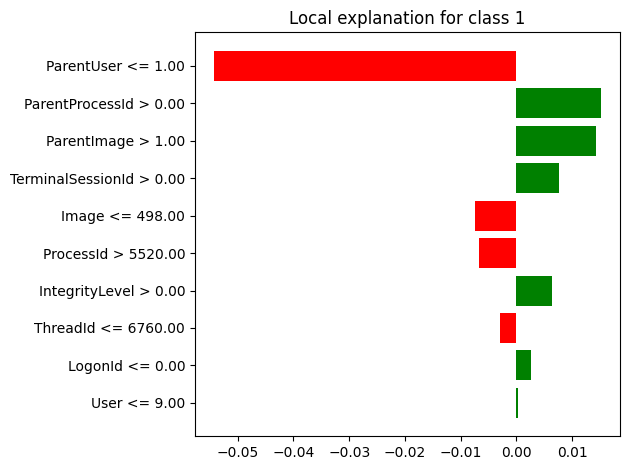

,feature,contribution
0,ParentUser <= 1.00,-0.054204
1,ParentProcessId > 0.00,0.015127
2,ParentImage > 1.00,0.014300
3,TerminalSessionId > 0.00,0.007692
4,Image <= 498.00,-0.007511
5,ProcessId > 5520.00,-0.006789
6,IntegrityLevel > 0.00,0.006433
7,ThreadId <= 6760.00,-0.002960
8,LogonId <= 0.00,0.002561
9,User <= 9.00,0.000218


In [44]:
instance_idx = 0
lime_explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[str(c) for c in classes],
    mode="classification",
)

exp = lime_explainer.explain_instance(
    X_logs.iloc[instance_idx].values,
    rf.predict_proba,
    num_features=10,
)

print(exp.as_list())
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

df_lime = pd.DataFrame(exp.as_list(), columns=["feature", "contribution"])
df_lime

In [71]:
REPORT_DIR = ROOT / "Tests" / "Reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pred_path = REPORT_DIR / "predictions_by_event.csv"
summary_path = REPORT_DIR / "summary_by_log.csv"
report_path = REPORT_DIR / "report.md"
dataset_path = REPORT_DIR / "logs_dataset_for_predict.csv"

df_logs.to_csv(pred_path, index=False)
summary.to_csv(summary_path, index=False)

dataset_for_predict = X_logs.copy()
dataset_for_predict.insert(0, "_log_file", df_logs["_log_file"].values)
dataset_for_predict.to_csv(dataset_path, index=False)

report_lines = []
report_lines.append("# Relatorio de testes com logs Sysmon")
report_lines.append("")
report_lines.append(f"Logs processados: {len(summary)}")
report_lines.append(f"Eventos totais: {len(df_logs)}")
report_lines.append("")
report_lines.append("## Metricas (assumindo todos os eventos como ransomware)")
report_lines.append(f"- accuracy: {acc:.4f}")
report_lines.append(f"- recall: {rec:.4f}")
report_lines.append("")
report_lines.append("## Predicao por log")
for _, row in summary.iterrows():
    label_txt = "RANSOMWARE" if row["log_pred_label"] == pos_label else "NAO RANSOMWARE"
    report_lines.append(
        f"- {row['_log_file']}: {label_txt} (rate={row['predicted_ransomware_rate']:.2f}, avg_prob={row['avg_prob_ransomware']:.3f})"
    )
report_lines.append("")
report_lines.append("## Resumo por log")
report_lines.append(summary.to_string(index=False))
report_lines.append("")
report_lines.append("Arquivos gerados:")
report_lines.append(f"- {pred_path}")
report_lines.append(f"- {summary_path}")
report_lines.append(f"- {dataset_path}")

report_path.write_text("\n".join(report_lines), encoding="utf-8")
print("Report saved:", report_path)
report_path

Report saved: C:\Projetos\RansonwareData\Tests\Reports\report.md


WindowsPath('C:/Projetos/RansonwareData/Tests/Reports/report.md')

In [65]:
# Dataset com campo predict
predict_path = REPORT_DIR / "logs_dataset_with_predict.csv"

dataset_with_predict = dataset_for_predict.copy()
if "pred_label" in df_logs.columns:
    dataset_with_predict["predict"] = df_logs["pred_label"].values
else:
    dataset_with_predict["predict"] = pd.Series([None] * len(dataset_with_predict))
    print("pred_label column not found in df_logs")

dataset_with_predict.to_csv(predict_path, index=False)
print("Dataset with predict saved:", predict_path)


Dataset with predict saved: C:\Projetos\RansonwareData\Tests\Reports\logs_dataset_with_predict.csv


In [47]:
# Count total events and group by EventID
print("Total events:", len(df_logs))

if "EventID" in df_logs.columns:
    event_counts = df_logs["EventID"].value_counts().sort_index()
    display(event_counts)
else:
    print("EventID column not found in df_logs")

Total events: 685


EventID
1     100
11    515
13      5
2       3
22     10
5      52
Name: count, dtype: int64

In [66]:
# Dataset com resultados dos logs + groupby EventID
results_path = REPORT_DIR / "logs_results_dataset.csv"

cols = [c for c in ["_log_file", "EventID", "pred_label", "prob_ransomware"] if c in df_logs.columns]
df_results = df_logs[cols].copy()
df_results.to_csv(results_path, index=False)
print("Results dataset saved:", results_path)

if "EventID" in df_results.columns:
    event_counts_results = df_results["EventID"].value_counts().sort_index()
    display(event_counts_results)
else:
    print("EventID column not found in df_results")

Results dataset saved: C:\Projetos\RansonwareData\Tests\Reports\logs_results_dataset.csv


EventID
1     100
11    515
13      5
2       3
22     10
5      52
Name: count, dtype: int64

In [70]:
# Checagem de linhas com pred_label=1 (ransomware)
if "pred_label" in df_logs.columns:
    ransomware_count = int((df_logs["pred_label"] == 1).sum())
    total_count = int(len(df_logs))
    print(f"ransomware_count: {ransomware_count} / {total_count}")
    if ransomware_count == 0:
        print("Nenhuma linha com pred_label=1 no df_logs.")
else:
    print("pred_label column not found in df_logs")


ransomware_count: 669 / 685


In [50]:
import json
sample_train = df_train.head(2).to_dict(orient="records")
sample_test = X_logs.head(2).to_dict(orient="records")

diff_cols = set(X_train_raw.columns) - set(df_logs.columns)
print(f"Columns in X_train_raw but NOT in df_logs: {len(diff_cols)}")
for c in list(diff_cols)[:10]:
    print(c)


Columns in X_train_raw but NOT in df_logs: 0


In [51]:
print("Sample 1 from Train dataset (first 10 features):")
sample_train = df_train[X_train_raw.columns].iloc[0]
print(sample_train.head(10))

print("\nSample 1 from df_logs (EVTX) (first 10 features):")
print(df_logs[df_logs.columns[:10]].iloc[0])

print("\nValue formatting differences (ProcessID vs Execution_ProcessID):")
if "Execution_ProcessID" in X_train_raw.columns:
    print("Train Execution_ProcessID:", df_train["Execution_ProcessID"].iloc[0])
if "ProcessID" in df_logs.columns:
    print("EVTX ProcessID:", df_logs["ProcessID"].iloc[0])


Sample 1 from Train dataset (first 10 features):
ProcessId                                                         5676
ThreadId                                                          6840
ParentProcessId                                                24272.0
LogonId                                                       0xc81b96
TerminalSessionId                                                  2.0
IntegrityLevel                                                    High
Image                   C:\Users\chrsm\AppData\Local\Temp\_iu14D2N.tmp
User                                             LAPTOP-ROPR18AK\chrsm
ParentImage          C:\Program Files (x86)\FOXIT SOFTWARE\FOXIT RE...
ParentUser                                       LAPTOP-ROPR18AK\chrsm
Name: 0, dtype: object

Sample 1 from df_logs (EVTX) (first 10 features):
_log_file                                cerber.evtx
Name                        Microsoft-Windows-Sysmon
Guid          {5770385f-c22a-43e0-bf4c-06f5698ffbd9}
EventID 

In [52]:
df_train_num = X_train_raw.select_dtypes(include=["int64", "float64"]).columns
df_logs_num = df_logs.select_dtypes(include=["int64", "float64"]).columns

print("Train numerical columns:", list(df_train_num))
print("Test (EVTX) numerical columns:", list(df_logs_num))

print("\nMissing cols filled with default (in X_logs):")
missing_in_test = [c for c in X_train_raw.columns if c not in df_logs.columns]
print(missing_in_test)


Train numerical columns: ['ProcessId', 'ThreadId', 'ParentProcessId', 'TerminalSessionId']
Test (EVTX) numerical columns: ['pred_label', 'prob_ransomware']

Missing cols filled with default (in X_logs):
[]


In [68]:
# Analisando especificamente os logs do Cerber com o novo modelo

df_cerber = df_logs[df_logs["_log_file"] == "cerber.evtx"]
X_cerber = X_logs[df_logs["_log_file"] == "cerber.evtx"]

print(f"Total Cerber events: {len(df_cerber)}")
print(f"Predicted as Ransomware: {(df_cerber['pred_label'] == 1).sum()}")

sample_cerber = X_cerber.iloc[0:2]

explainer_cerber = shap.TreeExplainer(rf)
sv_cerber = explainer_cerber.shap_values(sample_cerber)
if isinstance(sv_cerber, list):
    sv_cerber = sv_cerber[1] 
elif len(sv_cerber.shape) == 3:
    sv_cerber = sv_cerber[:, :, 1]

for i in range(len(sample_cerber)):
    print(f"\n--- Cerber Event {i} ---")
    print("Prob Ransomware:", df_cerber.iloc[i]["prob_ransomware"])
    print("EventID:", df_cerber.iloc[i].get("EventID", "N/A"))
    print("Image:", df_cerber.iloc[i].get("Image", "N/A"))
    
    contributions = sv_cerber[i]
    neg_idx = contributions.argsort()[:3]
    print("Top factors DECREASING ransomware probability (SHAP):")
    for idx in neg_idx:
        fname = X_logs.columns[idx]
        val = sample_cerber.iloc[i][fname]
        impact = contributions[idx]
        print(f"  {fname}={val} (impact: {impact:.4f})")


Total Cerber events: 478
Predicted as Ransomware: 18

--- Cerber Event 0 ---
Prob Ransomware: 0.7117637486985484
EventID: 1
Image: C:\Windows\System32\wevtutil.exe
Top factors DECREASING ransomware probability (SHAP):
  Image=432 (impact: -0.0744)
  ParentUser=-1 (impact: -0.0065)
  IntegrityLevel=2 (impact: 0.1073)

--- Cerber Event 1 ---
Prob Ransomware: 0.6780088580908413
EventID: 1
Image: C:\Lab\Samples\Cerber\cerber.exe
Top factors DECREASING ransomware probability (SHAP):
  ParentUser=-1 (impact: -0.0479)
  IntegrityLevel=4 (impact: 0.0050)
  ParentImage=186 (impact: 0.1113)
